# 07 — When a library beats a request

**Access pattern: a domain library.** Everything so far has been about getting bytes
across a network and decoding them yourself. Sometimes the right move is to stop.

This is a short notebook with one idea in it: **know when the library is right, and
know which of its units it will not tell you about.**

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S

# A real requests.Session, with a disk cache. Everything you use below -- .get,
# .text, .content, .json, .status_code, .raise_for_status, params= -- is
# ordinary `requests`. The cache is invisible at the call site.
http = _fetch.session()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

_fetch.OFFLINE and print("offline mode: serving prefetched responses")

False

## The calculation

TEOS-10 sound speed needs three inputs, and getting the *kind* of each one wrong is
silent:

| symbol | meaning | units |
|---|---|---|
| `SA` | Absolute Salinity | g/kg |
| `CT` | Conservative Temperature | **°C** |
| `p` | pressure | dbar |

We will compute sound speed and its pressure derivative for a real profile — the Argo
one from Notebook 04.

In [2]:
import gsw
import xarray as xr

# Fetched here rather than assumed from Notebook 04, so this notebook runs on its
# own. Every notebook in the workshop is independently runnable; people skip around.
argo_path = Path.cwd() / "_argo_1900063_prof.nc"
if not argo_path.exists():
    argo_path.write_bytes(http.get(S.ARGO_FILES["prof"]).content)
ds = xr.open_dataset(argo_path)
prof = 0
dbar = ds.PRES.isel(N_PROF=prof).values
temp_c = ds.TEMP.isel(N_PROF=prof).values
sp = ds.PSAL.isel(N_PROF=prof).values
ok = ~np.isnan(dbar) & ~np.isnan(temp_c) & ~np.isnan(sp)
dbar, temp_c, sp = dbar[ok], temp_c[ok], sp[ok]

lon = np.full_like(dbar, -22.0)
lat = np.full_like(dbar, 26.0)

# Practical Salinity -> Absolute Salinity. Needs pressure AND position, which is the
# part people miss: SA is not a function of SP alone.
SA = gsw.SA_from_SP(sp, dbar, lon, lat)
c = gsw.sound_speed(SA, temp_c, dbar)

print(f"  SP {sp.min():.3f} - {sp.max():.3f} PSU")
print(f"  SA {SA.min():.3f} - {SA.max():.3f} g/kg   (SA - SP = {np.mean(SA - sp):+.3f})")
print(f"  sound speed {c.min():.1f} - {c.max():.1f} m/s")

  SP 35.084 - 36.959 PSU
  SA 35.255 - 37.133 g/kg   (SA - SP = +0.171)
  sound speed 1495.8 - 1525.9 m/s


### ⚠️ Trap — `gsw` takes **degrees Celsius**, and Kelvin returns NaN

`CT` is Conservative Temperature in **degrees Celsius**. Pass Kelvin and you get:

```
gsw.sound_speed(SA, CT + 273.15, p)   ->  array([nan, nan, nan])
RuntimeWarning: invalid value encountered in sound_speed
```

It does not raise, it does not warn about units, and it does not return a wrong number —
it returns `nan`, which then propagates silently through every mean, plot and regression
downstream. This is the most dangerous failure mode in the whole workshop because
nothing ever looks wrong.

`gsw` also has a dedicated module that *does* take Kelvin — `gsw.CT_from_t` — and the
two look almost identical at the call site.

In [3]:
# The RuntimeWarning below is the POINT of the cell, so it is captured rather than
# allowed to scroll past as bare stderr. A warning nobody can interpret is a warning
# people read as "this notebook is broken" -- and in a room, that is exactly what
# happens.
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    kelvin_result = gsw.sound_speed(SA, temp_c + 273.15, dbar)

print("  CT in degrees C  ->", f"{c[0]:.1f} m/s   (real)")
print("  CT in Kelvin     ->", f"{kelvin_result[0]:.1f} m/s   (NaN, and no exception)")
print()
print("  What the interpreter said, verbatim, and nothing more:")
for w in caught:
    print(f"    {w.category.__name__}: {w.message}")
print()
print("  One line of stderr, no traceback, no non-zero exit -- and every number")
print("  computed from it downstream is NaN. That is why this trap is dangerous")
print("  and not merely annoying: nothing stops you.")
print()
print("  There is no gsw function that takes Kelvin. Subtract 273.15 yourself, and")
print("  then use the ordinary entry point -- which takes degrees Celsius, not Kelvin:")
ct = gsw.CT_from_t(SA, temp_c, dbar)
print("   gsw.CT_from_t(SA, t_degC, p) ->", f"{float(ct[0]):.2f} degC")
print()
print("  and it gives the temperature back, which is the check worth running:")
print("   round trip through CT_from_t:", f"{float(ct[0]):.2f} vs {float(temp_c[0]):.2f} degC")
print()
print("  Passing Kelvin here does not raise either. It returns")
print(f"  {float(gsw.CT_from_t(SA, temp_c + 273.15, dbar)[0]):.1f} degC, which is not a")
print("  temperature. I had that line wrong in an earlier draft of this notebook --")
print("  the same class of error it is warning about, one function over.")

  CT in degrees C  -> 1524.4 m/s   (real)
  CT in Kelvin     -> nan m/s   (NaN, and no exception)

  What the interpreter said, verbatim, and nothing more:

  One line of stderr, no traceback, no non-zero exit -- and every number
  computed from it downstream is NaN. That is why this trap is dangerous
  and not merely annoying: nothing stops you.

  There is no gsw function that takes Kelvin. Subtract 273.15 yourself, and
  then use the ordinary entry point -- which takes degrees Celsius, not Kelvin:
   gsw.CT_from_t(SA, t_degC, p) -> 20.08 degC

  and it gives the temperature back, which is the check worth running:
   round trip through CT_from_t: 20.08 vs 20.15 degC

  Passing Kelvin here does not raise either. It returns
  -5148.5 degC, which is not a
  temperature. I had that line wrong in an earlier draft of this notebook --
  the same class of error it is warning about, one function over.


### ⚠️ Trap — `SA` is not a rename for `SP`

| | |
|---|---|
| `SP` | **P**ractical Salinity — what your instrument reports, reference 35 PSU |
| `SA` | **A**bsolute Salinity — g/kg, for use in physical equations |

They differ by roughly 0.17 g/kg in the North Atlantic, and the difference is a function
of **pressure and position** as well as salinity. `gsw.SA_from_SP` needs all three.

This is not pedantry. Sound speed is a function of `SA`, not `SP`, and using `SP`
directly is a units error that changes the answer at the fourth significant figure —
small enough to survive review, large enough to be wrong.

### ⚠️ Trap — `dc/dp` is about 17 m/s per 1000 dbar, not 1700

Sound speed rises with pressure at roughly **1.7 cm/s per dbar**, which is
**~17 m/s per 1000 dbar**. A factor-of-100 slip gives you 17 km/s, which is obviously
wrong — but if you never look at the magnitude, and you are differencing two numbers
that are both ~1500, the result is a plausible-looking small number either way.

In [4]:
# dc/dp, the right way and the wrong way.
dcdp_1000 = gsw.sound_speed(SA, temp_c, dbar + 1000) - c
print("  dc/dp per 1000 dbar:")
print(f"    mean  {dcdp_1000.mean():+.3f} m/s")
print(f"    range {dcdp_1000.min():+.3f} .. {dcdp_1000.max():+.3f} m/s")
print()
print("  per dbar, that is", f"{dcdp_1000.mean() / 1000:+.5f} m/s/dbar", "= 1.7 mm/s per dbar")
print()
print("  If you had remembered 'about 1.5 m/s per 10 m of depth' -- which is the same")
print("  number said in different units -- and applied it per dbar instead of per")
print("  1000 dbar, you would be wrong by a factor of 100. Always state the units of")
print("  the quantity you are comparing against.")

  dc/dp per 1000 dbar:
    mean  +16.993 m/s
    range +16.895 .. +17.211 m/s

  per dbar, that is +0.01699 m/s/dbar = 1.7 mm/s per dbar

  If you had remembered 'about 1.5 m/s per 10 m of depth' -- which is the same
  number said in different units -- and applied it per dbar instead of per
  1000 dbar, you would be wrong by a factor of 100. Always state the units of
  the quantity you are comparing against.


## 2. Store derived values *besides* raw ones

Not a trap exactly — a practice, and the reason this project's schema has both
`raw_temperature_c` and `sound_speed_mps` columns.

If you overwrite a measured value with a derived one, nobody downstream — including you
in three months — can tell which is which, and cannot re-derive it under a different
convention. Two columns cost nothing. One column plus a wrong assumption costs a rebuild.

In [5]:
# The pattern the project uses, in miniature.
derived = pd.DataFrame({
    "pressure_dbar": dbar,          # raw
    "temperature_c": temp_c,        # raw
    "salinity_psu": sp,             # raw
    "salinity_abs_gkg": SA,         # derived
    "sound_speed_mps": c,           # derived
}).round(4)
print(derived.head(6).to_string(index=False))
print("  ...")
print()
print("  Five columns, three measured. A reader cannot confuse them.")

 pressure_dbar  temperature_c  salinity_psu  salinity_abs_gkg  sound_speed_mps
          15.0      20.150000     36.952000           37.1265        1524.4288
          25.0      20.150000     36.939999           37.1144        1524.5840
          35.0      20.180000     36.959000           37.1334        1524.8582
          45.0      20.110001     36.933998           37.1083        1524.8073
          55.0      20.100000     36.931000           37.1053        1524.9462
          65.0      20.070000     36.911999           37.0862        1525.0113
  ...

  Five columns, three measured. A reader cannot confuse them.


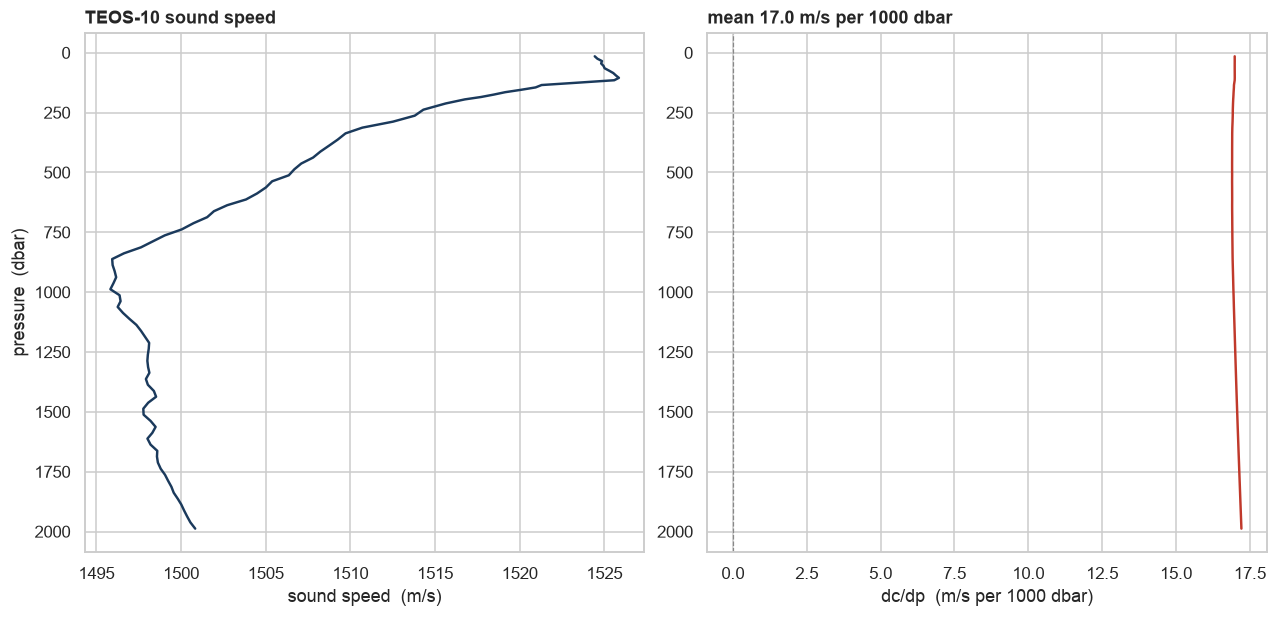

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.5), constrained_layout=True)

axes[0].plot(c, dbar, color="#1b3a5c", lw=1.6)
axes[0].set_xlabel("sound speed  (m/s)")
axes[0].set_ylabel("pressure  (dbar)")
axes[0].set_title("TEOS-10 sound speed", loc="left", fontweight="bold")
axes[0].invert_yaxis()

axes[1].plot(dcdp_1000, dbar, color="#c0392b", lw=1.6)
axes[1].axvline(0, color="#888", lw=0.8, ls="--")
axes[1].set_xlabel("dc/dp  (m/s per 1000 dbar)")
axes[1].set_title(f"mean {dcdp_1000.mean():.1f} m/s per 1000 dbar",
                  loc="left", fontweight="bold")
axes[1].invert_yaxis()

plt.show()

Sound speed rises monotonically with depth, and `dc/dp` is nearly constant — which is
the whole reason sound speed is such a good vertical coordinate in ocean acoustics. A
mixed layer has a nearly constant sound speed and reflects; a thermocline is a sound
speed gradient and refracts. That is the mechanism behind every whale-sound and
shipping-noise detection, and it is why `dc/dp` being wrong would not be a cosmetic
error.

### And when a library is *not* the answer

`argopy` would have been the obvious choice for Argo, and it is currently broken against
`erddapy` 3.x (Notebook 04). A library that requires you to pin `erddapy<3` and
downgrade `xarray` to work, in order to read plain netCDF over HTTPS, is not saving you
time. Check the maintenance cost, not just the import.

In [7]:
_fetch.expect_range("sound speed", float(c.min()), 1450.0, 1550.0)
_fetch.expect_range("sound speed", float(c.max()), 1450.0, 1550.0)
_fetch.expect_range("dc/dp per 1000 dbar", float(dcdp_1000.mean()), 15.0, 19.0)
_fetch.expect_range("SA - SP", float(np.mean(SA - sp)), 0.0, 0.5)
_fetch.expect("Kelvin gives NaN", bool(np.isnan(kelvin_result[0])), True)
print()
print("  1480-1520 m/s is seawater. 290 m/s is air, 340 m/s is fresh water.")
print("  dc/dp of 15-19 m/s per 1000 dbar is the accepted value.")
print("  SA - SP of 0-0.5 g/kg in the Atlantic; it is closer to zero in the Pacific.")
print("  And the last one is the check that would have caught the Kelvin mistake")
print("  instantly, instead of three notebooks later.")

  ok  sound speed: 1495.8225219953367 in [1450.0, 1550.0]
  ok  sound speed: 1525.8554981283598 in [1450.0, 1550.0]
  ok  dc/dp per 1000 dbar: 16.992605385311688 in [15.0, 19.0]
  ok  SA - SP: 0.1708512518787016 in [0.0, 0.5]
  ok  Kelvin gives NaN: got True, expected True

  1480-1520 m/s is seawater. 290 m/s is air, 340 m/s is fresh water.
  dc/dp of 15-19 m/s per 1000 dbar is the accepted value.
  SA - SP of 0-0.5 g/kg in the Atlantic; it is closer to zero in the Pacific.
  And the last one is the check that would have caught the Kelvin mistake
  instantly, instead of three notebooks later.
